## Лабораторная работа №1 — Взвешенная нелинейная регрессия
### Вариант 1 - Фомин Павел Андреевич - ИСТм-126

Реализация последовательности работы из методических указаний на Python для Jupyter Notebook.

Модель:
\[
y=b_1(1-e^{-b_2x})
\]

Вариант 1:
- `x = [1, 2, 3, 5, 7, 10]`
- `y = [109, 149, 149, 191, 213, 224]`
- `w = [5, 5, 1, 1, 1, 1]`


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit
from scipy.stats import t, f

np.set_printoptions(precision=6, suppress=True)

# Исходные данные — вариант 1
x = np.array([1, 2, 3, 5, 7, 10], dtype=float)
y = np.array([109, 149, 149, 191, 213, 224], dtype=float)
w = np.array([5, 5, 1, 1, 1, 1], dtype=float)

print("x =", x)
print("y =", y)
print("w =", w)


x = [ 1.  2.  3.  5.  7. 10.]
y = [109. 149. 149. 191. 213. 224.]
w = [5. 5. 1. 1. 1. 1.]


## 1. Точечный график исходных данных

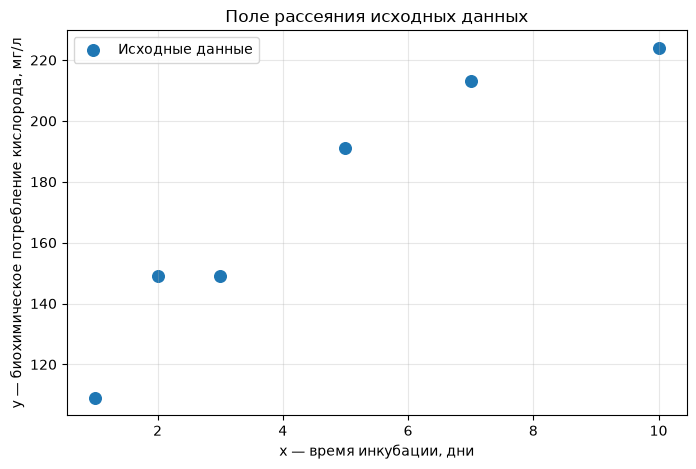

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=70, label="Исходные данные")
plt.xlabel("x — время инкубации, дни")
plt.ylabel("y — биохимическое потребление кислорода, мг/л")
plt.title("Поле рассеяния исходных данных")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 2. Нелинейная модель и начальные значения

Выбирается масштабированная экспоненциальная модель:

`y = b1 * (1 - exp(-b2 * x))`

Основываясь на грубой визуальной оценке можно заметить, что кривая, проведенная через точки, может выровняться около 240, поэтому берём `b1 = 240`. В качестве начального значения скорости насыщения используется `b2 = 0.5`.


In [14]:
def model(x, b1, b2):
    return b1 * (1 - np.exp(-b2 * x))

start = [240.0, 0.5]
print("Начальные значения [b1, b2] =", start)


Начальные значения [b1, b2] = [240.0, 0.5]


## 3. Вспомогательные функции для оценки качества модели

In [15]:
def metrics(y_true, y_pred, n_params=2):
    residuals = y_true - y_pred
    n = len(y_true)
    sse = np.sum(residuals**2)
    mse = sse / (n - n_params)
    rmse = np.sqrt(mse)

    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - sse / ss_tot

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1)

    return {
        "SSE": sse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adj_r2,
        "Residuals": residuals
    }

def print_metrics(name, result):
    print(name)
    for key in ["SSE", "RMSE", "R2", "Adjusted R2"]:
        print(f"{key:15s}: {result[key]:.6f}")


## 4. Модель без учёта весов

Параметры невзвешенной модели:
b1 = 213.809533
b2 = 0.547236
Показатели качества:
SSE            : 1168.008877
RMSE           : 17.088072
R2             : 0.880468
Adjusted R2    : 0.800780


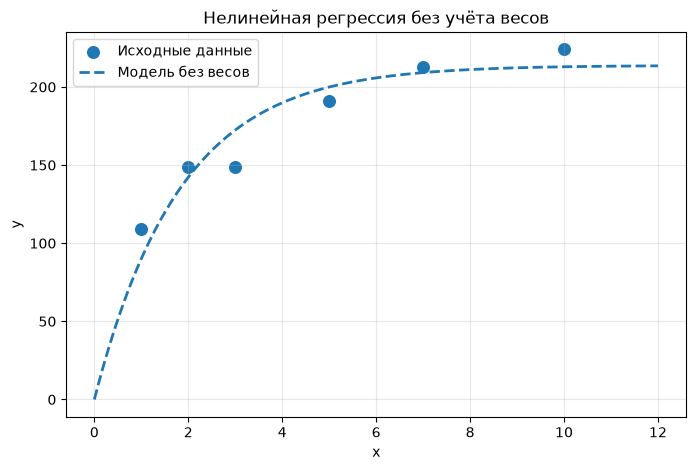

In [16]:
# Невзвешенная нелинейная регрессия
popt_unw, pcov_unw = curve_fit(
    model, x, y,
    p0=start,
    maxfev=10000
)

y_unw = model(x, *popt_unw)
res_unw = metrics(y, y_unw)

print("Параметры невзвешенной модели:")
print(f"b1 = {popt_unw[0]:.6f}")
print(f"b2 = {popt_unw[1]:.6f}")
print_metrics("Показатели качества:", res_unw)

xx = np.linspace(0, 12, 300)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=70, label="Исходные данные")
plt.plot(xx, model(xx, *popt_unw), "--", linewidth=2,
         label="Модель без весов")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Нелинейная регрессия без учёта весов")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 5. Модель с учётом весов

Для метода наименьших квадратов веса реализуются через стандартные отклонения:

`\sigma_i = \frac{1}{\sqrt{w_i}}`

Тогда минимизируется взвешенная сумма квадратов ошибок:

`sum_i w_i(y_i-\hat y_i)^2`



Параметры взвешенной модели:
b1 = 206.757117
b2 = 0.666923
Взвешенный RMSE: 20.831240
Невзвешенные показатели качества для сравнения:
SSE            : 1412.495300
RMSE           : 18.791589
R2             : 0.855447
Adjusted R2    : 0.759079


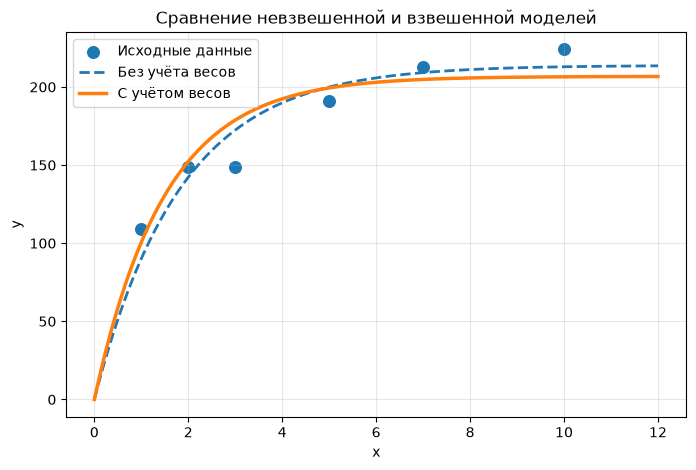

In [17]:
sigma = 1 / np.sqrt(w)

popt_w, pcov_w = curve_fit(
    model, x, y,
    p0=start,
    sigma=sigma,
    absolute_sigma=False,
    maxfev=10000
)

y_w = model(x, *popt_w)
res_w = metrics(y, y_w)

weighted_sse = np.sum(w * (y - y_w)**2)
weighted_rmse = np.sqrt(weighted_sse / (len(x) - len(popt_w)))

print("Параметры взвешенной модели:")
print(f"b1 = {popt_w[0]:.6f}")
print(f"b2 = {popt_w[1]:.6f}")
print(f"Взвешенный RMSE: {weighted_rmse:.6f}")
print_metrics("Невзвешенные показатели качества для сравнения:", res_w)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=70, label="Исходные данные")
plt.plot(xx, model(xx, *popt_unw), "--", linewidth=2,
         label="Без учёта весов")
plt.plot(xx, model(xx, *popt_w), linewidth=2.5,
         label="С учётом весов")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Сравнение невзвешенной и взвешенной моделей")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6. Оценка точности параметров и 95%-доверительные интервалы

In [18]:
n = len(x)
p = len(popt_w)
dof = n - p                

se = np.sqrt(np.diag(pcov_w)) # Стандартные ошибки параметров
t_stat = popt_w / se 

p_values = 2 * (1 - t.cdf(np.abs(t_stat), dof)) 

alpha = 0.05 
tcrit = t.ppf(1 - alpha / 2, dof)

coef_ci = np.column_stack([
    popt_w - tcrit * se,
    popt_w + tcrit * se
])

coef_table = pd.DataFrame(
    {
        "Estimate": popt_w,
        "SE": se,
        "tStat": t_stat,
        "pValue": p_values
    },
    index=["b1", "b2"]
)

coef_table["Estimate"] = coef_table["Estimate"].map(lambda v: f"{v:.6g}")
coef_table["SE"] = coef_table["SE"].map(lambda v: f"{v:.6g}")
coef_table["tStat"] = coef_table["tStat"].map(lambda v: f"{v:.6g}")
coef_table["pValue"] = coef_table["pValue"].map(lambda v: f"{v:.6g}")

y_pred = model(x, *popt_w)
residuals = y - y_pred                  # Остатки
weighted_sse = np.sum(w * residuals**2) # Взвешенная сумма квадратов ошибок
rmse = np.sqrt(weighted_sse / dof)      # Среднеквадратичная ошибка
weighted_mean = np.sum(w * y) / np.sum(w)          # Взвешенное среднее
weighted_sst = np.sum(w * (y - weighted_mean)**2)  # Полная взвешенная сумма квадратов
r_squared = 1 - weighted_sse / weighted_sst        # R-квадрат

adjusted_r_squared = (1 - (1 - r_squared) * (n - 1) / (n - p - 1)) # Скорректированный R-квадрат

# F-статистика
f_statistic = (
    (r_squared / (p - 1))
    /
    ((1 - r_squared) / (n - p))
)

# p-значение F-статистики
f_pvalue = 1 - f.cdf(f_statistic, p - 1, n - p)

display(coef_table)

print(f"\nNumber of observations: {n}, Error degrees of freedom: {dof}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"R-Squared: {r_squared:.3f}, Adjusted R-Squared: {adjusted_r_squared:.3f}")
print(f"F-statistic vs. zero model: {f_statistic:.3f}, p-value = {f_pvalue:.4g}")

,Estimate,SE,tStat,pValue
b1,206.757,12.8914,16.0384,8.83752e-05
b2,0.666923,0.100515,6.63505,0.00267739



Number of observations: 6, Error degrees of freedom: 4
Root Mean Squared Error: 20.831
R-Squared: 0.911, Adjusted R-Squared: 0.851
F-statistic vs. zero model: 40.843, p-value = 0.003077


## 7. Доверительные интервалы для регрессионной кривой

Строятся приближённые 95%-одновременные интервалы. Для модели с двумя параметрами используется градиент функции относительно параметров и ковариационная матрица оценок.


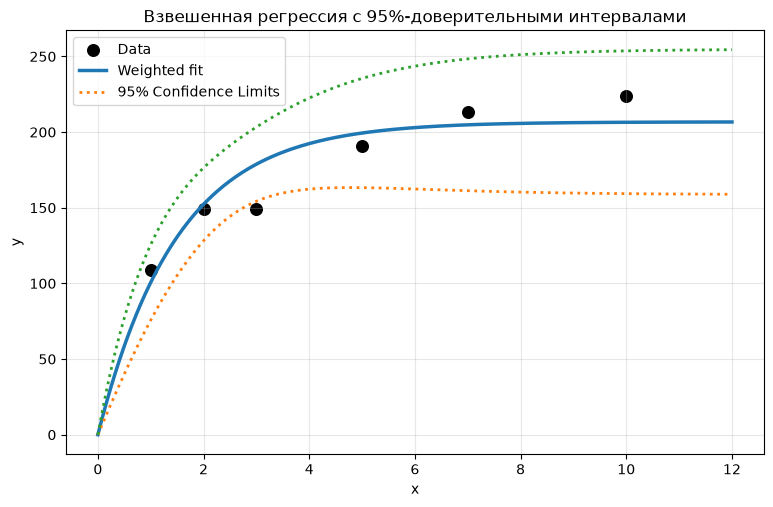

In [19]:
def jacobian_model(xv, b1, b2):
    xv = np.asarray(xv)
    e = np.exp(-b2 * xv)

    # Производные по b1 и b2
    db1 = 1 - e
    db2 = b1 * xv * e

    return np.column_stack([db1, db2])

ypred = model(xx, *popt_w)
J = jacobian_model(xx, *popt_w)

# Дисперсия среднего прогнозируемого значения
var_pred = np.einsum("ij,jk,ik->i", J, pcov_w, J)
se_pred = np.sqrt(np.maximum(var_pred, 0))

# Приближённый одновременный 95%-интервал по Шеффе
Fcrit = f.ppf(1 - alpha, p, dof)
scheffe_factor = np.sqrt(p * Fcrit)

halfwidth = scheffe_factor * se_pred
lower_ci = ypred - halfwidth
upper_ci = ypred + halfwidth

plt.figure(figsize=(9, 5.5))
plt.scatter(x, y, s=70, color="black", label="Data")
plt.plot(xx, ypred, linewidth=2.5, label="Weighted fit")
plt.plot(xx, lower_ci, ":", linewidth=2, label="95% Confidence Limits")
plt.plot(xx, upper_ci, ":", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Взвешенная регрессия с 95%-доверительными интервалами")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 8. Модель для одинаковых весов 5

Согласно методике, ширину интервалов для наблюдения, представляющего среднее по пяти измерениям, уменьшаем в `sqrt(5)` раз.


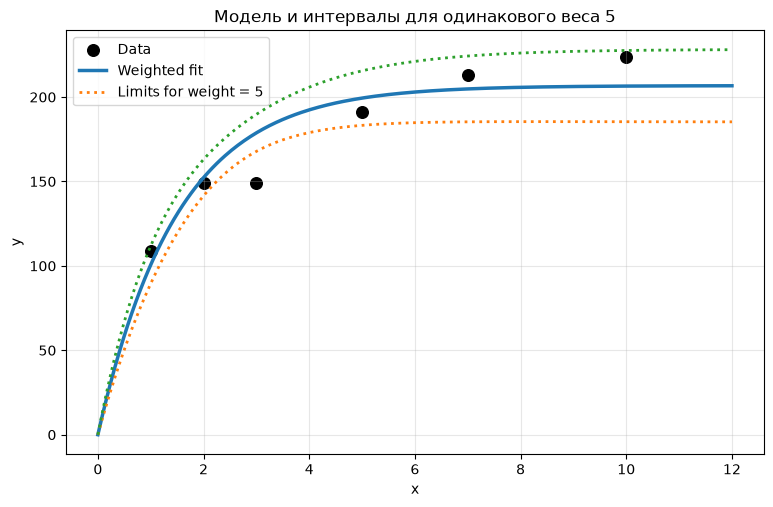

In [20]:
halfwidth_weight5 = halfwidth / np.sqrt(5)

lower_ci_w5 = ypred - halfwidth_weight5
upper_ci_w5 = ypred + halfwidth_weight5

plt.figure(figsize=(9, 5.5))
plt.scatter(x, y, s=70, color="black", label="Data")
plt.plot(xx, ypred, linewidth=2.5, label="Weighted fit")
plt.plot(xx, lower_ci_w5, ":", linewidth=2, label="Limits for weight = 5")
plt.plot(xx, upper_ci_w5, ":", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Модель и интервалы для одинакового веса 5")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9. Анализ остатков

Стандартизированные по весам остатки:

\[
r_i^* = (y_i-\hat y_i)\sqrt{w_i}
\]

Используется знак `y - y_fit`. При обратном определении остатка (`y_fit - y`) график будет зеркально отражён относительно горизонтальной оси.


Таблица остатков:
x=  1.0, y= 109.00, residual=   8.3683, weighted residual=  18.7122
x=  2.0, y= 149.00, residual=  -3.2844, weighted residual=  -7.3442
x=  3.0, y= 149.00, residual= -29.7971, weighted residual= -29.7971
x=  5.0, y= 191.00, residual=  -8.3907, weighted residual=  -8.3907
x=  7.0, y= 213.00, residual=   8.1837, weighted residual=   8.1837
x= 10.0, y= 224.00, residual=  17.5053, weighted residual=  17.5053


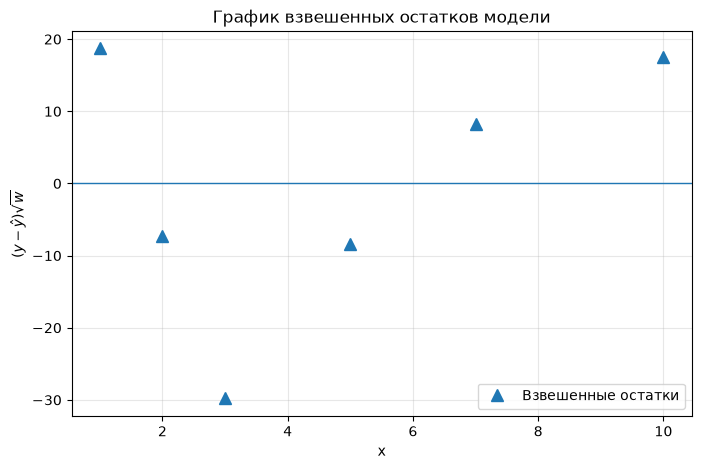

In [21]:
raw_residuals = y - y_w
weighted_residuals = raw_residuals * np.sqrt(w)

print("Таблица остатков:")
for xi, yi, ri, rwi in zip(x, y, raw_residuals, weighted_residuals):
    print(f"x={xi:5.1f}, y={yi:7.2f}, residual={ri:9.4f}, weighted residual={rwi:9.4f}")

plt.figure(figsize=(8, 5))
plt.axhline(0, linewidth=1)
plt.plot(x, weighted_residuals, "^", markersize=9,
         label="Взвешенные остатки")
plt.xlabel("x")
plt.ylabel(r"$(y - \hat{y})\sqrt{w}$")
plt.title("График взвешенных остатков модели")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
